## Exercise 2, Experiment notebook
_Using `Multinomial Logistic Regression`_

<br>
<br>




### Dataset: [Student Alcohol Consumption](https://www.kaggle.com/datasets/uciml/student-alcohol-consumption)

|Parameter|Description|
|---|---|
|Shape|`__`|
|Target Variable|`__`|
|Method:|`__`
|Extra Tools:|`__`|

<br>

<i>
<strong style='color:red ; background-color:black;'> 

#### Disclosure: 

I used AI to convert the table from the kaggle dataset webpage into a markdown table.

#### Prompt:

 /paste Kaggle column descriptions/. 
 
 Could you put this into a markdown table for me? 
 
</strong>
</i>

| Column Number | Column Name | Column Description                                                             |
| ------------- | ----------- | ------------------------------------------------------------------------------ |
| 1             | school      | Student’s school (binary: GP = Gabriel Pereira, MS = Mousinho da Silveira)     |
| 2             | sex         | Student’s sex (binary: F = female, M = male)                                   |
| 3             | age         | Student’s age (numeric: 15–22)                                                 |
| 4             | address     | Home address type (binary: U = urban, R = rural)                               |
| 5             | famsize     | Family size (binary: LE3 ≤ 3, GT3 > 3)                                         |
| 6             | Pstatus     | Parent cohabitation status (binary: T = together, A = apart)                   |
| 7             | Medu        | Mother’s education (0 none, 1 primary, 2 5th–9th grade, 3 secondary, 4 higher) |
| 8             | Fedu        | Father’s education (same scale as Medu)                                        |
| 9             | Mjob        | Mother’s job (teacher, health, services, at_home, other)                       |
| 10            | Fjob        | Father’s job (teacher, health, services, at_home, other)                       |
| 11            | reason      | Reason for choosing school (home, reputation, course, other)                   |
| 12            | guardian    | Student’s guardian (mother, father, other)                                     |
| 13            | traveltime  | Travel time to school (1 <15m, 2 15–30m, 3 30–60m, 4 >60m)                     |
| 14            | studytime   | Weekly study time (1 <2h, 2 2–5h, 3 5–10h, 4 >10h)                             |
| 15            | failures    | Past class failures (n if 1≤n<3, else 4)                                       |
| 16            | schoolsup   | Extra educational support (yes/no)                                             |
| 17            | famsup      | Family educational support (yes/no)                                            |
| 18            | paid        | Extra paid classes (yes/no)                                                    |
| 19            | activities  | Extra-curricular activities (yes/no)                                           |
| 20            | nursery     | Attended nursery school (yes/no)                                               |
| 21            | higher      | Wants higher education (yes/no)                                                |
| 22            | internet    | Internet access at home (yes/no)                                               |
| 23            | romantic    | Romantic relationship (yes/no)                                                 |
| 24            | famrel      | Family relationship quality (1 very bad → 5 excellent)                         |
| 25            | freetime    | Free time after school (1 very low → 5 very high)                              |
| 26            | goout       | Going out with friends (1 very low → 5 very high)                              |
| 27            | Dalc        | Workday alcohol consumption (1 very low → 5 very high)                         |
| 28            | Walc        | Weekend alcohol consumption (1 very low → 5 very high)                         |
| 29            | health      | Current health status (1 very bad → 5 very good)                               |
| 30            | absences    | Number of school absences (0–93)                                               |


#### Summary:

<i>
In this notebook, I'll be using Multinomial Logistic Regression to determine the workday alcohol consumption of a student `Dalc`. I was initially confused with what Multinomial Logistic Regression is, so I'll write it down here so I remember. Multinomial Logistic Regression <strong style='color:red; background-color:black'>IS NOT using multiple target variables</strong>, it is <strong style='color:orange ; background-color:black;'> using categorical or ordinal-type target variables instead of binary type target variables. </strong>

THE CAVEAT is that it has an absurdly low amount of rows. 395 rows. Can I even make a model with that few rows, 5 target selections, and a horrible distribution? Let's find out and test some boundaries.

<br>
<br>


#### Note:

We have no idea what the `G1`, `G2`, and `G3` columns mean. They could be class groups? 

#### Results:



<br>
<br>


---

## Code:

#### Imports and Data Loading

In [23]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# Loading dataframe
df = pd.read_csv("../datasets/students.csv")
df.head(3)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10


---

### Data Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation & Feature Engineering|
|3| ML Training & Metrics|

#### Checking the Shape

In [24]:
# Let's check the amount of rows and columns
df.shape

(395, 33)

#### Handling Missing Values

In [25]:
# Checking for missing values
df.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

#### Handling Duplicates

In [26]:
df.duplicated().sum()

np.int64(0)

#### Handling Isolated Case values

In [27]:
# Since we have a metric ton of columns, let's make a for-loop that 
# gives the value counts of all the columns that mmay have isolated cases.
list_checkable_columns = list(df.columns)

for column in list_checkable_columns:
    print(df[column].value_counts())
    print()

school
GP    349
MS     46
Name: count, dtype: int64

sex
F    208
M    187
Name: count, dtype: int64

age
16    104
17     98
18     82
15     82
19     24
20      3
22      1
21      1
Name: count, dtype: int64

address
U    307
R     88
Name: count, dtype: int64

famsize
GT3    281
LE3    114
Name: count, dtype: int64

Pstatus
T    354
A     41
Name: count, dtype: int64

Medu
4    131
2    103
3     99
1     59
0      3
Name: count, dtype: int64

Fedu
2    115
3    100
4     96
1     82
0      2
Name: count, dtype: int64

Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

guardian
mother    273
father     90
other      32
Name: count, dtype: int64

traveltime
1    257
2    107
3     23
4      8
Name: count, d

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">


<i>
<h3>Observations</h3>

`Medu` (mother's education) and `Fedu`(father's education) have some isolated cases where the parents don't have any education at all. There's only up to 3 rows worth of cases for these situations.

Let's get rid of these cases.
</div>
</i>

In [28]:
# Using a multifilter to get rid of isolated cases.
# We CANNOT blindly get rid of a bunch of rows, we need to be
# quite selective here.
df = df[
    (df['Fedu'] != 0) &
    (df['Medu'] != 0) &
    (df['age'] <= 19) 
]

# SANITY CHECK -- No more isolated cases?
print(df['Medu'].value_counts())
print(df['Fedu'].value_counts())
print(df['age'].value_counts())
# Very good. 

Medu
4    129
2    102
3     97
1     57
Name: count, dtype: int64
Fedu
2    110
3    100
4     96
1     79
Name: count, dtype: int64
age
16    102
17     97
18     82
15     81
19     23
Name: count, dtype: int64


#### Transforming Columns to Numbers

<i>

Now, let's encode all the string columns to numbers.

#### Categorical

<i>
Let's start by converting all the nominal features.

In [29]:
# We'll be turning all these into binary numeric column.
# I'll write the justifications for why it's categorical 
# in side-comments.
categorical_columns = [
  # "school",              # binary, only two school values in this field.
  # "address",             # binary, two possible values. U = urban, R = rural.
  # "Pstatus",             # binary, two possible values. T = together, A = apart.
    "Mjob",                # other, services, at_home, teacher, health
    "Fjob",                # other, services, at_home, teacher, health
    "reason",              # course, home, reputation, other.
    "guardian"             # Mother, father, other.
]

# OneHotEncoder to transform each categorical to separate, binary numeric.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)

# Dropping one column from each categorical variable, since it can
# deduce these values anyways.
df = df.drop([
    "Mjob_other",
    "Fjob_other",
    "guardian_other",
], axis=1)

df.head(3)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_at_home,Fjob_health,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother
0,GP,F,18,U,GT3,A,4,4,2,2,...,0,0,0,1,1,0,0,0,0,1
1,GP,F,17,U,GT3,T,1,1,1,2,...,0,0,0,0,1,0,0,0,1,0
2,GP,F,15,U,LE3,T,1,1,1,2,...,0,0,0,0,0,0,1,0,0,1


#### Encoding Binary Values

In [30]:
# A list of binary columns to iterate over.
variables = ['school', 'sex', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

# For each column in the `variables` list... apply the binary encoder.
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

# A helper guide for common cases (mostly for me)
# For yes/no columns : No=0, Yes=1
# For person_gender  : Female=0, Male=1

#### Encoding Binary Variables (Mapper Edition)

<i>
These are also binary variables, but I would like them in a particular order so I can interpret the results.

In [31]:
# -- FAMILY SIZE --
# Creating a dict for all the ordinal values of a column
category_mapper = {
    'LE3':0,       # Less than three family members.
    'GT3':1,       # More than three family members
}

# Use the hashmap approach to map encode columnar values.
df['famsize'] = df['famsize'].map(category_mapper)

# -- PSTATUS --
# Creating a dict for all the ordinal values of a column
category_mapper = {
    'A':0,         # Parents are apart.
    'T':1,         # Parents are together
}

# Use the hashmap approach to map encode columnar values.
df['Pstatus'] = df['Pstatus'].map(category_mapper)

# -- ADDRESS --
# Creating a dict for all the ordinal values of a column
category_mapper = {
    'R':0,         # Parents are apart.
    'U':1,         # Parents are together
}

# Use the hashmap approach to map encode columnar values.
df['address'] = df['address'].map(category_mapper)

# SANITY CHECK -- Did I mislabel anything? (it would show as NaN)
df.isna().sum()

# Looks good.


school               0
sex                  0
age                  0
address              0
famsize              0
Pstatus              0
Medu                 0
Fedu                 0
traveltime           0
studytime            0
failures             0
schoolsup            0
famsup               0
paid                 0
activities           0
nursery              0
higher               0
internet             0
romantic             0
famrel               0
freetime             0
goout                0
Dalc                 0
Walc                 0
health               0
absences             0
G1                   0
G2                   0
G3                   0
Mjob_at_home         0
Mjob_health          0
Mjob_services        0
Mjob_teacher         0
Fjob_at_home         0
Fjob_health          0
Fjob_services        0
Fjob_teacher         0
reason_course        0
reason_home          0
reason_other         0
reason_reputation    0
guardian_father      0
guardian_mother      0
dtype: int6

In [32]:
# SANITY CHECK 2 -- Did we encode everything?
df.head(5)

# Let's check if each of these columns has a only numbers in it.

# Yep, looks like everything is encoded.

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_at_home,Fjob_health,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother
0,0,0,18,1,1,0,4,4,2,2,...,0,0,0,1,1,0,0,0,0,1
1,0,0,17,1,1,1,1,1,1,2,...,0,0,0,0,1,0,0,0,1,0
2,0,0,15,1,0,1,1,1,1,2,...,0,0,0,0,0,0,1,0,0,1
3,0,0,15,1,1,1,4,2,1,3,...,0,0,1,0,0,1,0,0,0,1
4,0,0,16,1,1,1,3,3,1,2,...,0,0,0,0,0,1,0,0,1,0


#### Dropping Unnecessary Columns

In [33]:
# Let's drop the weekend drinking column, since obviously that will be 
# directly correlative (and multicorrelative) with `Dalc`(workday drinking).
# NO CHEATING.
df = df.drop([
    "Walc"
], axis=1)

---

### Transformation & Feature Engineering

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|<bold style="background:yellow;color:black;">  Transformation & Feature Engineering</bold>|
|3| ML Training & Metrics|

<br>
<br>

<i>


#### Checking out the distribution of the target variable.

<Axes: xlabel='Dalc', ylabel='Count'>

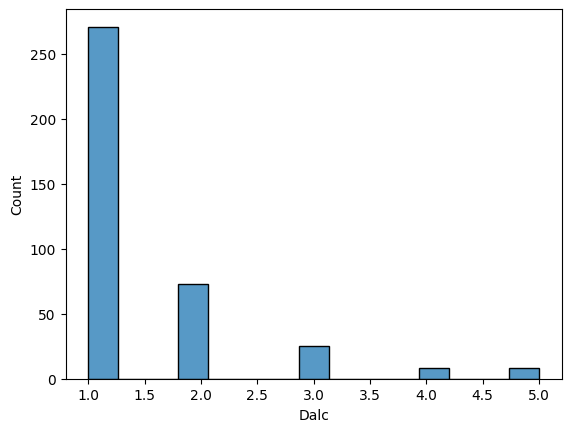

In [34]:
sns.histplot(df, x='Dalc')

#### Checking out the distribution of some features. 

In [35]:
df_exp = df.copy()

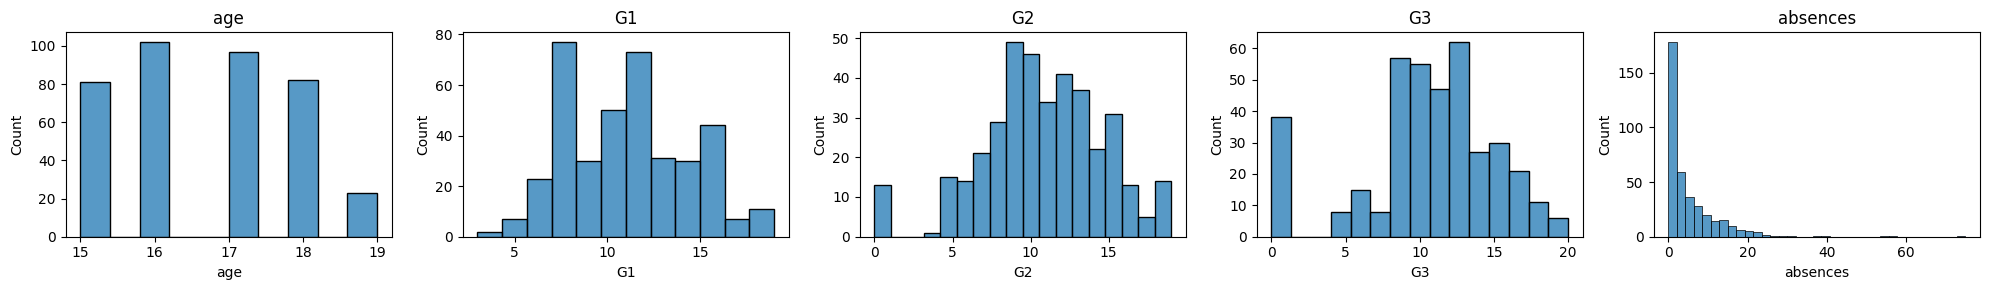

In [36]:
# Let's iterate over the numeric columns with high ranges.
columns_list = ["age", "G1", "G2", "G3", "absences"]

# We create a canvas with 5 subsplots
fig, axes = plt.subplots(1, 5, figsize=(20, 3))

# Create a histplot for every column in column_list.
for index, column in enumerate(columns_list):
    sns.histplot(df_exp, x=column, ax=axes[index])
    axes[index].set_title(column)

# Prevents overlap between graphs
plt.tight_layout()


# Mostly normal distributions, with the exception of absences. StandardScaler() might balance that out a bit, let's see. 

#### What if we used `StandardScaler()`?

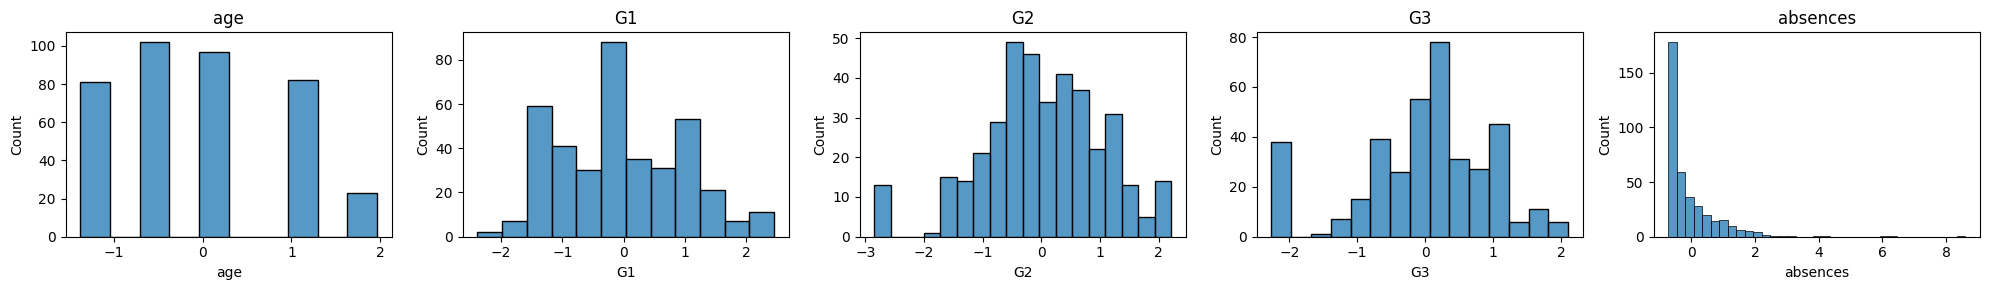

In [37]:
scaler = StandardScaler()
np_array = scaler.fit_transform(df_exp)
df_exp = pd.DataFrame(
    np_array,
    columns=df_exp.columns,
    index=df_exp.index
)

fig, axes = plt.subplots(1, 5, figsize=(20, 3))

for index, column in enumerate(columns_list):

    sns.histplot(df_exp, x=column, ax=axes[index])
    axes[index].set_title(column)

# Prevents overlap between graphs
plt.tight_layout()

<i>

Nope, that wouldn't work at all. `StandardScaler()` doesn't help with the right-skew...

But if we were to use transformation on all of them, we might have an adverse result as well. I'm suspecting the `pipeline` and `ColumnTransformation` method might be the best here. 

Let's try using log transform on the `absences` feature instead and see if it positively affects the result. 



#### Experimenting with `Pipeline` & `ColumnTransformer`

<i>

This creates an experimental pipeline which runs `log1p` on the `absences`feature and `StandardScaler()` on the rest of the columns. I'll admit, it's a little long-winded -- But the reasoning for this is so we have a better distribution fit before we train our model.

In [38]:
# First, we make a copy of the dataframe, fresh reset. 
df_exp = df.copy()

# Second, we tell pandas to give us every other column than the
# `absences` column. 
remainder_cols = df.drop('absences', axis=1).columns

# Third, we create a preprocessor. 
# A: Log transform absences
# B: use StandardScaler on every other columns 
preprocessor = ColumnTransformer(transformers=[
    ('log', FunctionTransformer(np.log1p), ['absences']),
    ('scaled', StandardScaler(), remainder_cols)
])

# Fourth, we set the output to pandas -- We want to keep the column names.
preprocessor.set_output(transform="pandas")

# Fifth, set the pipeline to run through the processor.
pipeline = Pipeline([
    ('preprocessing', preprocessor)
])

# Sixth, fit the data using the pipeline. 
df_exp = pipeline.fit_transform(df_exp)

# Viola, we now have a pipeline that runs Log on the `absences` column, `StandardScaler`` on everything else.
df_exp.head(3)

,log__absences,scaled__school,scaled__sex,scaled__age,scaled__address,scaled__famsize,scaled__Pstatus,scaled__Medu,scaled__Fedu,scaled__traveltime,...,scaled__Fjob_at_home,scaled__Fjob_health,scaled__Fjob_services,scaled__Fjob_teacher,scaled__reason_course,scaled__reason_home,scaled__reason_other,scaled__reason_reputation,scaled__guardian_father,scaled__guardian_mother
0,1.945910,-0.354586,-0.937043,1.130197,0.540321,0.640513,-2.978556,1.147654,1.345450,0.785368,...,-0.227843,-0.221464,-0.628433,3.503693,1.330332,-0.624413,-0.311233,-0.608364,-0.548339,0.656679
1,1.609438,-0.354586,-0.937043,0.295023,0.540321,0.640513,0.335733,-1.660695,-1.444487,-0.640890,...,-0.227843,-0.221464,-0.628433,-0.285413,1.330332,-0.624413,-0.311233,-0.608364,1.823689,-1.522815
2,2.397895,-0.354586,-0.937043,-1.375326,0.540321,-1.561249,0.335733,-1.660695,-1.444487,-0.640890,...,-0.227843,-0.221464,-0.628433,-0.285413,-0.751692,-0.624413,3.213025,-0.608364,-0.548339,0.656679


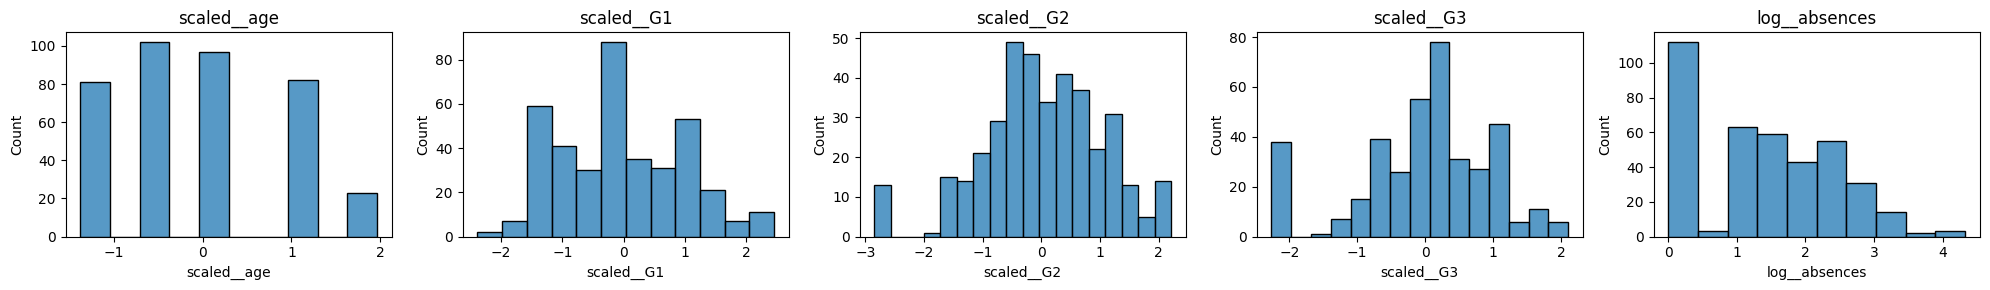

In [39]:
# Let's iterate over the numeric columns with high ranges.
columns_list = ["scaled__age", "scaled__G1", "scaled__G2", "scaled__G3", "log__absences"]

fig, axes = plt.subplots(1, 5, figsize=(20, 3))

for index, column in enumerate(columns_list):

    sns.histplot(df_exp, x=column, ax=axes[index])
    axes[index].set_title(column)

# Prevents overlap between graphs
plt.tight_layout()

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<i>

As an experiment, let's use `make_pipeline` and `Pipeline` with `ColumnTransformation` and compare the results. in the ML training section below.

 <strong>For science! </strong> 

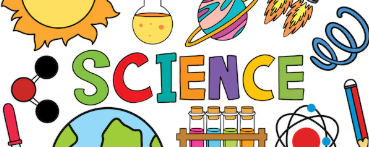

</div>

#### Feature Selection

<i>

For feature selection, we're going to use the penalty parameter for 

---

### ML Training & Metrics

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|Transformation & Feature Engineering|
|3|<bold style="background:yellow;color:black;">   ML Training & Metrics </bold>|

`ColumnTransformation`

              precision    recall  f1-score   support

           1       0.71      0.92      0.80       108
           2       0.11      0.03      0.05        29
           3       0.25      0.12      0.17         8
           4       0.00      0.00      0.00         5
           5       0.00      0.00      0.00         4

    accuracy                           0.66       154
   macro avg       0.21      0.22      0.20       154
weighted avg       0.53      0.66      0.58       154


Model overall accuracy: 65.58%


c:\Users\kykis\Intro_ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kykis\Intro_ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kykis\Intro_ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<Axes: >

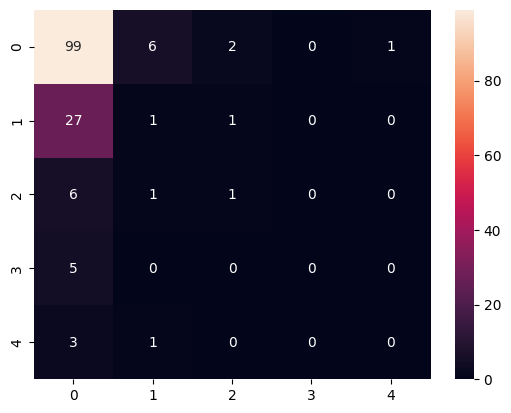

In [40]:
# Constants (These are used to log the parameters in mlflow, that way I can remember what works)
XY_SPLIT = 0.4

# Defining dependent, independent variables.
X = df.drop("Dalc", axis=1)
y = df['Dalc']

# Get all the columns except `absences`
remainder_cols = X.columns.difference(["absences"])

# train/test-split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=XY_SPLIT, random_state=101)

# Column transformer
preprocessor = ColumnTransformer([
    ('log', FunctionTransformer(np.log1p), ['absences']),
    ('scaled', StandardScaler(), X.columns.difference(['absences']))
])
preprocessor.set_output(transform='pandas')

# RFE setup
rfe = RFE(
    estimator=LogisticRegression(max_iter=5000, solver='saga'),
    n_features_to_select=10
)

# Run a pipeline
pipeline = make_pipeline(
    preprocessor,
    rfe,
    LogisticRegression(solver='saga', max_iter=5000)
)

# Train
pipeline.fit(X_train, y_train)

# Predict
predictions = pipeline.predict(X_test)

# Metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

print(classification_report(y_test, predictions))
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g')

ValueError: multi_class must be in ('ovo', 'ovr')

---

### Personal Analysis